# Phase 2 — Notebook 07 · Stage 2.3 (planning §Stage 2.5) · Pooled GKF on 6 balanced sessions

**Why this notebook exists.** Stage 2.2 closed with: hash-aware Design B + attention pooling improves global metrics, but L2/3 recall still trails Tier G's scalar fingerprint and class-balanced loss did not fix it. The user's call: **stop single-session tuning, scale to multi-session training**. This notebook does the within-protocol pooled scaling step (planning §Stage 2.5); notebook 08 will do the cross-session LOSO step (planning §Stage 2.6).

**Stage scope (planning §Stage 2.5):**

* 6 four-class balanced sessions: `5_6, 5_7, 6_2, 6_4, 6_6, 6_7`.
* Consistent-only neurons (mismatch-removed, planning §1.3).
* Pooled GroupKFold by `nucleus_id` (5 folds), neuron-level scoring.
* Primary architecture: **Design B + hash embedding + attention pooling** (winning model from NB 04 §12).
* Secondary architecture (gated by `RUN_MEAN_POOL`): **Design B + hash embedding + mean pooling**, for direct comparison if attention turns out to overfit.

**What this stage tests:**

1. **Does more data help globally?** Compare pooled-GKF metrics to NB 04 within-session 5_6.
2. **Does L2/3 recover with more data?** This is the class-imbalance question revisited at pool scale: in the pool, L2/3 is the *majority* class (≈45%) while L6 is now the rare class (≈7%). The class-imbalance problem from Stage 2.2 has *flipped*.
3. **Is the model overfitting?** With more parameters of freedom (attention pool with hash embeddings, ~3,400 training neurons) we need to carefully track val/test gap, train loss vs val accuracy curves, and per-session test breakdown.
4. **Is the architecture stable across folds?** Tighter SD across folds is itself evidence of stability; large per-fold swings warn against scaling further to LOSO.

**Class composition flips (warning):**

| | session 5_6 (NB 04) | pooled 6 sessions |
|---|---:|---:|
| L2/3 | 22% | **45%** |
| L4   | 36% | 24% |
| L5   | 28% | 24% |
| L6   | 14% | **7%** |

Inverse-frequency weights on the pool are roughly: L2/3 = 0.56, L4 = 1.05, L5 = 1.03, L6 = **3.50**. So the same loss that over-predicted L6 on 5_6 alone will over-predict L6 even more strongly on the pool. This is a known consequence of the data; we report what the loss does and read the result against expectation, rather than retuning the loss in this notebook (single-session loss tuning was rejected in NB 06).

**Methodological contract (binding):**

1. Working pool of V1-excitatory best-only neurons, mismatch-removed. Sessions: `5_6, 5_7, 6_2, 6_4, 6_6, 6_7`.
2. E1 = `(nucleus_id × oracle condition_hash)` with within-hash trial-averaged trace `response_avg`. No across-hash averaging (planning §2.3).
3. Padded traces, `T = MAX_TRACE_LEN = 113`, masked GAP per trace.
4. Hash vocabulary fitted globally on all 116 oracle hashes; same integer indexing across folds.
5. **GroupKFold by `nucleus_id`, 5 folds**. Each fold uses `(k+1) mod 5` as the validation fold for early stopping. No neuron in more than one of `{train, val, test}`.
6. Loss: class-weighted CE with **inverse-frequency** weights computed on training neurons only (matches NB 04 model B; NB 06 showed CB does not help on this corpus).
7. Hash-aware Design B architecture identical to NB 04 (trace_embed=64, hash_embed=16, row_hidden=64, head_hidden=64, dropout=0.25, kernel=5).
8. Per-fold seeds = `SEED + fold_k = {42, 43, 44, 45, 46}` (matches the seed strategy of NB 02 / 04 / 05 / 06).
9. **Overfitting guards**: track best-epoch distribution, gap = (best val bal-acc) − (test bal-acc), per-session test bal-acc breakdown.

Outputs: `data/processed/results/phase2_stage2_3_pooled_gkf_balanced.parquet` (per-fold + summary rows, both pools when `RUN_MEAN_POOL=True`).

## 0 · Environment

In [18]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import GroupKFold

from src.config import PROCESSED_RESULTS_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    build_pooled_e1,
    MAX_TRACE_LEN,
    load_oracle_hashes,
)
from src.models.cnn import LAYER_CLASSES
from src.models.cnn_deepsets import (
    HashAwareDeepSetsTraceCNN,
    build_e1_neuron_tensors_with_hashes,
    train_design_b_hash_fold,
    predict_neuron_proba_hash,
    neuron_score_design_b,
)
from src.eval.cnn_eval import save_results, make_result_row

warnings.filterwarnings('ignore', category=UserWarning)

BALANCED_SESSIONS = ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7']
SEED        = 42
N_FOLDS     = 5
MAX_EPOCHS  = 50            # reduced vs NB 04 (was 80) — pool training is slower per epoch
PATIENCE    = 8             # reduced vs NB 04 (was 12)
BATCH_SIZE  = 32
TRACE_EMBED = 64
HASH_EMBED  = 16
ROW_HIDDEN  = 64
HEAD_HIDDEN = 64
DROPOUT     = 0.25

# Architecture toggles
RUN_ATTENTION_POOL = True       # primary model — leave True
RUN_MEAN_POOL      = True      # secondary — set True if you have time (~doubles compute)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device         : {DEVICE}')
print(f'Sessions pooled: {BALANCED_SESSIONS}')
print(f'CV protocol    : GroupKFold(n_splits={N_FOLDS}) by nucleus_id (across all sessions)')
print(f'Architectures  : attention_pool={RUN_ATTENTION_POOL}, mean_pool={RUN_MEAN_POOL}')
print(f'Training caps  : max_epochs={MAX_EPOCHS}, patience={PATIENCE}, batch_size={BATCH_SIZE}')
print(f'Seed strategy  : SEED + fold_k')

Device         : mps
Sessions pooled: ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7']
CV protocol    : GroupKFold(n_splits=5) by nucleus_id (across all sessions)
Architectures  : attention_pool=True, mean_pool=True
Training caps  : max_epochs=50, patience=8, batch_size=32
Seed strategy  : SEED + fold_k


## 1 · Population & pooled E1 dataset

Memory-efficient build: `build_pooled_e1` reads `traces_avg.parquet` once with pyarrow predicate pushdown (filtered on `session_key ∈ BALANCED_SESSIONS` and `condition_hash ∈ oracle-116`), so the working set never exceeds the actually-needed rows.

In [2]:
units_raw = load_working_pop()
units_clean, mismatch_report = remove_mismatch_neurons(units_raw, verbose=False)

# Per-session mismatch summary (for the 6 balanced sessions)
rows = []
for s in BALANCED_SESSIONS:
    raw_n   = int((units_raw.session_key == s).sum())
    clean_n = int((units_clean.session_key == s).sum())
    rows.append({'session': s, 'raw': raw_n, 'clean': clean_n,
                 'pct_kept': f'{100 * clean_n / raw_n:.1f}%',
                 'pct_dropped': f'{100 * (raw_n - clean_n) / raw_n:.1f}%'})
print('Per-session mismatch removal:\n')
print(pd.DataFrame(rows).to_string(index=False))

df_pool = build_pooled_e1(BALANCED_SESSIONS, units_clean, verbose=True)

# Drop any neuron that doesn't have full oracle coverage (so the set-tensor
# build assertion of uniform coverage holds). This should be 0 in practice.
cov = df_pool.groupby('nucleus_id')['condition_hash'].nunique()
incomplete = cov[cov < 116].index.tolist()
if incomplete:
    print(f'\n⚠️  Dropping {len(incomplete)} neurons with incomplete oracle coverage.')
    df_pool = df_pool[~df_pool['nucleus_id'].isin(incomplete)].reset_index(drop=True)

n_neurons = df_pool['nucleus_id'].nunique()
print(f'\nFinal pooled E1: {n_neurons} neurons × 116 hashes = {len(df_pool):,} rows')
print(f'\nClass composition (per-neuron):')
print(df_pool.drop_duplicates('nucleus_id')['layer_label'].value_counts().sort_index().to_string())
frac = df_pool.drop_duplicates('nucleus_id')['layer_label'].value_counts(normalize=True).sort_index()
print(f"\nClass fractions: " + ' '.join(f'{c}={frac[c]:.2%}' for c in LAYER_CLASSES))
print('\n⚠️  Class composition is dramatically different from session 5_6 alone (NB 04):')
print('     5_6 alone : L2/3=22% L4=36% L5=28% L6=14% → L6 over-prediction was the bug')
print('     pool      : L2/3=45% L4=24% L5=24% L6= 7% → L6 over-prediction will be even worse')
print('     The L2/3 collapse from Stage 2.2 may RESOLVE in this regime simply because L2/3')
print('     becomes a majority class — but if it does, that is a class-prior effect, not')
print('     evidence that the architecture itself improved.')

Per-session mismatch removal:

session  raw  clean pct_kept pct_dropped
    5_6  686    685    99.9%        0.1%
    5_7  701    696    99.3%        0.7%
    6_2  774    734    94.8%        5.2%
    6_4  916    824    90.0%       10.0%
    6_6  697    606    86.9%       13.1%
    6_7  874    712    81.5%       18.5%
Pooling 6 sessions: ['5_6', '5_7', '6_2', '6_4', '6_6', '6_7']
  Population (mismatch-clean): 4257 neurons
session_key
5_6    685
5_7    696
6_2    734
6_4    824
6_6    606
6_7    712

  Pooled E1 rows: 493,812
  Neurons with data: 4,257
  Oracle coverage per neuron: min=116 median=116 max=116

  Per-session row count:
session_key
5_6    79460
5_7    80736
6_2    85144
6_4    95584
6_6    70296
6_7    82592

Final pooled E1: 4257 neurons × 116 hashes = 493,812 rows

Class composition (per-neuron):
layer_label
L2/3    1909
L4      1011
L5      1033
L6       304

Class fractions: L2/3=44.84% L4=23.75% L5=24.27% L6=7.14%

⚠️  Class composition is dramatically different from s

## 2 · Hash vocabulary — same global mapping as NB 04 / NB 05 / NB 06

In [3]:
oracle_hashes, oracle_by_family = load_oracle_hashes()
HASH_VOCAB = sorted(oracle_hashes)
N_HASHES   = len(HASH_VOCAB)
assert N_HASHES == 116
print(f'Hash vocabulary: {N_HASHES} oracle hashes')
print(f'  Clip   : {oracle_by_family["Clip"]}')
print(f'  Monet2 : {oracle_by_family["Monet2"]}')
print(f'  Trippy : {oracle_by_family["Trippy"]}')

Hash vocabulary: 116 oracle hashes
  Clip   : 96
  Monet2 : 10
  Trippy : 10


## 3 · GKF folds — by `nucleus_id` across all 6 sessions

5-fold GroupKFold over the unique nucleus_ids in the pooled population. Sessions are mixed across folds (a fold has neurons from all 6 sessions, in proportion to each session's share of the pool). This is *within-protocol* generalisation — the cross-session test is in notebook 08 (LOSO).

We also report per-fold session composition so we can read whether any fold is dominated by one session.

In [4]:
neurons_df = df_pool[['nucleus_id', 'layer_label', 'session_key']].drop_duplicates().reset_index(drop=True)
neuron_ids = neurons_df['nucleus_id'].to_numpy()

gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_neuron = np.full(len(neuron_ids), -1, dtype=np.int8)
for k, (_, te_idx) in enumerate(gkf.split(neuron_ids, groups=neuron_ids)):
    fold_of_neuron[te_idx] = k
assert (fold_of_neuron >= 0).all()
neurons_df['gkf_fold'] = fold_of_neuron

fold_layer = neurons_df.groupby(['gkf_fold','layer_label']).size().unstack(fill_value=0)
print('Neurons per fold × layer:')
print(fold_layer.to_string())
assert (fold_layer > 0).all().all()

fold_session = neurons_df.groupby(['gkf_fold','session_key']).size().unstack(fill_value=0)
print('\nNeurons per fold × session:')
print(fold_session.to_string())

df_pool = df_pool.merge(neurons_df[['nucleus_id', 'gkf_fold']], on='nucleus_id', how='left')
print(f'\nTotal pooled rows: {len(df_pool):,}')

Neurons per fold × layer:
layer_label  L2/3   L4   L5  L6
gkf_fold                       
0             391  187  214  60
1             379  204  210  59
2             374  209  200  68
3             380  205  206  60
4             385  206  203  57

Neurons per fold × session:
session_key  5_6  5_7  6_2  6_4  6_6  6_7
gkf_fold                                 
0            143  126  153  182  113  135
1            132  147  137  142  138  156
2            136  141  151  160  117  146
3            146  134  149  172  111  139
4            128  148  144  168  127  136

Total pooled rows: 493,812


## 4 · Pack pooled E1 into per-neuron set-tensors

Same helper as NB 04 / NB 06. Hash ordering is consistent across neurons after sort, so a single `(116,)` int64 tensor of hash indices applies to every neuron in the batch.

In [5]:
X, mask, y_str, nids, hash_ids, hash_vocab = build_e1_neuron_tensors_with_hashes(
    df_pool, pad_to=MAX_TRACE_LEN, hash_vocab=HASH_VOCAB,
)
assert hash_vocab == HASH_VOCAB
assert hash_ids.shape == (N_HASHES,)
assert X.shape[0] == n_neurons

fold_lookup    = neurons_df.set_index('nucleus_id')['gkf_fold'].to_dict()
session_lookup = neurons_df.set_index('nucleus_id')['session_key'].to_dict()
fold_of    = np.array([fold_lookup[int(n)]    for n in nids], dtype=np.int8)
session_of = np.array([session_lookup[int(n)] for n in nids])

print(f'X        : {X.shape}  dtype={X.dtype}  (~{X.nbytes / 1e9:.2f} GB)')
print(f'mask     : {mask.shape}  valid_frac={mask.sum() / np.prod(mask.shape):.3f}')
print(f'fold_of  : counts {dict(zip(*np.unique(fold_of, return_counts=True)))}')
print(f'session_of distribution: {dict(zip(*np.unique(session_of, return_counts=True)))}')

X        : (4257, 116, 113)  dtype=float32  (~0.22 GB)
mask     : (4257, 116, 113)  valid_frac=0.722
fold_of  : counts {0: 852, 1: 852, 2: 851, 3: 851, 4: 851}
session_of distribution: {'5_6': 685, '5_7': 696, '6_2': 734, '6_4': 824, '6_6': 606, '6_7': 712}


## 5 · Per-fold runner — train hash-aware Design B with selectable pool

Same training contract as NB 04, with two additions: we capture **best epoch** (proxy for overfitting onset) and **per-session test bal-acc** (whether any session systematically fails).

In [6]:
def run_one_fold(fold_k: int, pool: str, seed: int = SEED, verbose: bool = False):
    val_k = (fold_k + 1) % N_FOLDS

    test_idx  = np.where(fold_of == fold_k)[0]
    val_idx   = np.where(fold_of == val_k)[0]
    train_idx = np.where(~np.isin(fold_of, [fold_k, val_k]))[0]

    assert (not (set(train_idx) & set(val_idx))) and (not (set(train_idx) & set(test_idx))) \
        and (not (set(val_idx) & set(test_idx))), 'neuron leakage detected'

    X_tr, M_tr, y_tr = X[train_idx], mask[train_idx], y_str[train_idx]
    X_va, M_va, y_va = X[val_idx],   mask[val_idx],   y_str[val_idx]
    X_te, M_te, y_te = X[test_idx],  mask[test_idx],  y_str[test_idx]
    sess_te          = session_of[test_idx]

    model, history = train_design_b_hash_fold(
        X_tr, M_tr, y_tr,
        X_va, M_va, y_va,
        hash_ids=hash_ids,
        n_hashes=N_HASHES,
        in_channels=1, n_classes=4,
        trace_embed=TRACE_EMBED, hash_embed=HASH_EMBED,
        row_hidden=ROW_HIDDEN, head_hidden=HEAD_HIDDEN,
        dropout=DROPOUT, kernel_size=5,
        pool=pool,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS, patience=PATIENCE,
        lr=1e-3, weight_decay=1e-4,
        seed=seed + fold_k,
        device=DEVICE,
        verbose=verbose,
    )

    neuron_probs = predict_neuron_proba_hash(
        model, X_te, hash_ids, mask=M_te,
        batch_size=BATCH_SIZE, device=DEVICE,
    )
    score = neuron_score_design_b(y_te, neuron_probs, classes=np.array(LAYER_CLASSES))

    # Overfitting diagnostic: best val bal-acc (post-load) vs test bal-acc
    val_probs = predict_neuron_proba_hash(
        model, X_va, hash_ids, mask=M_va,
        batch_size=BATCH_SIZE, device=DEVICE,
    )
    val_score = neuron_score_design_b(y_va, val_probs, classes=np.array(LAYER_CLASSES))

    score['val_bal_acc']        = val_score['balanced_accuracy']
    score['val_minus_test_gap'] = val_score['balanced_accuracy'] - score['balanced_accuracy']
    score['best_epoch']         = int(np.argmax([h['val_bal_acc'] for h in history])) + 1
    score['final_train_loss']   = float(history[-1]['train_loss'])
    score['n_epochs_run']       = len(history)

    # Per-session test breakdown
    per_session = {}
    for s in BALANCED_SESSIONS:
        sel = sess_te == s
        if sel.sum() == 0:
            per_session[s] = {'n': 0, 'bal_acc': float('nan'), 'recall': {c: float('nan') for c in LAYER_CLASSES}}
            continue
        from sklearn.metrics import balanced_accuracy_score, confusion_matrix
        y_true_s = y_te[sel]
        y_pred_s = np.array(LAYER_CLASSES)[neuron_probs[sel].argmax(axis=1)]
        if len(np.unique(y_true_s)) < 2:
            ba = float('nan')
        else:
            ba = balanced_accuracy_score(y_true_s, y_pred_s)
        cm = confusion_matrix(y_true_s, y_pred_s, labels=LAYER_CLASSES)
        recall = {}
        for i, c in enumerate(LAYER_CLASSES):
            denom = cm[i].sum()
            recall[c] = float(cm[i, i] / denom) if denom > 0 else float('nan')
        per_session[s] = {'n': int(sel.sum()), 'bal_acc': float(ba), 'recall': recall}
    score['per_session'] = per_session
    return score, history

print('Per-fold runner ready (with overfitting + per-session diagnostics).')

Per-fold runner ready (with overfitting + per-session diagnostics).


## 6 · Run all 5 folds — primary architecture (attention pool)

This is ~3,400 training neurons per fold, ~390k rows per epoch. With `BATCH_SIZE=32` (neurons) → ~110 batches/epoch. Expect ~20–40 min per fit on MPS, ~2–3 hours total for 5 folds. Logs print fold-level summary.

In [7]:
results   = {pk: [] for pk in ['attention', 'mean']}
histories = {pk: [] for pk in ['attention', 'mean']}

if RUN_ATTENTION_POOL:
    print(f'\n────────  Pooled GKF · attention pool · {len(BALANCED_SESSIONS)} balanced sessions  ────────')
    t0 = time.time()
    for k in range(N_FOLDS):
        ti = time.time()
        score, hist = run_one_fold(fold_k=k, pool='attention', seed=SEED, verbose=False)
        score['fold'] = k
        results['attention'].append(score)
        histories['attention'].append(hist)
        ba  = score['balanced_accuracy']
        f1  = score['macro_f1']
        pcr = score['per_class_recall']
        print(f'  fold {k} | n_test={score["n_neurons"]:4d} | bal_acc={ba:.4f} (val {score["val_bal_acc"]:.4f}, gap {score["val_minus_test_gap"]:+.4f}) '
              f'| F1={f1:.3f} | best_ep={score["best_epoch"]:>2d}/{score["n_epochs_run"]} '
              f'| recall: ' + ' '.join(f'{c}={pcr[c]:.2f}' for c in LAYER_CLASSES)
              + f'  ({time.time() - ti:.1f}s)')
    print(f'\nAttention pool total time: {(time.time() - t0) / 60:.1f} min')


────────  Pooled GKF · attention pool · 6 balanced sessions  ────────
  fold 0 | n_test= 852 | bal_acc=0.5587 (val 0.5517, gap -0.0070) | F1=0.476 | best_ep=15/23 | recall: L2/3=0.17 L4=0.50 L5=0.65 L6=0.92  (402.6s)
  fold 1 | n_test= 852 | bal_acc=0.5274 (val 0.5597, gap +0.0323) | F1=0.470 | best_ep= 8/16 | recall: L2/3=0.38 L4=0.30 L5=0.58 L6=0.85  (117.8s)
  fold 2 | n_test= 851 | bal_acc=0.5698 (val 0.5840, gap +0.0142) | F1=0.485 | best_ep=37/45 | recall: L2/3=0.11 L4=0.67 L5=0.59 L6=0.91  (734.9s)
  fold 3 | n_test= 851 | bal_acc=0.5603 (val 0.5609, gap +0.0006) | F1=0.430 | best_ep=15/23 | recall: L2/3=0.09 L4=0.61 L5=0.57 L6=0.97  (372.7s)
  fold 4 | n_test= 851 | bal_acc=0.5780 (val 0.5831, gap +0.0050) | F1=0.486 | best_ep=25/33 | recall: L2/3=0.09 L4=0.69 L5=0.67 L6=0.86  (549.0s)

Attention pool total time: 36.3 min


## 7 · Optional run — mean pool secondary architecture

Gated by `RUN_MEAN_POOL` at the top of the notebook. Set `RUN_MEAN_POOL = True` and re-run from §6 if you want the side-by-side comparison.

In [19]:
if RUN_MEAN_POOL:
    print(f'\n────────  Pooled GKF · mean pool · {len(BALANCED_SESSIONS)} balanced sessions  ────────')
    t0 = time.time()
    for k in range(N_FOLDS):
        ti = time.time()
        score, hist = run_one_fold(fold_k=k, pool='mean', seed=SEED, verbose=False)
        score['fold'] = k
        results['mean'].append(score)
        histories['mean'].append(hist)
        ba  = score['balanced_accuracy']
        f1  = score['macro_f1']
        pcr = score['per_class_recall']
        print(f'  fold {k} | n_test={score["n_neurons"]:4d} | bal_acc={ba:.4f} (val {score["val_bal_acc"]:.4f}, gap {score["val_minus_test_gap"]:+.4f}) '
              f'| F1={f1:.3f} | best_ep={score["best_epoch"]:>2d}/{score["n_epochs_run"]} '
              f'| recall: ' + ' '.join(f'{c}={pcr[c]:.2f}' for c in LAYER_CLASSES)
              + f'  ({time.time() - ti:.1f}s)')
    print(f'\nMean pool total time: {(time.time() - t0) / 60:.1f} min')
else:
    print('Mean pool skipped (RUN_MEAN_POOL=False). Re-run §6 with RUN_MEAN_POOL=True if needed.')


────────  Pooled GKF · mean pool · 6 balanced sessions  ────────
  fold 0 | n_test= 852 | bal_acc=0.5566 (val 0.5656, gap +0.0090) | F1=0.458 | best_ep=24/32 | recall: L2/3=0.11 L4=0.54 L5=0.63 L6=0.95  (433.0s)
  fold 1 | n_test= 852 | bal_acc=0.5556 (val 0.5608, gap +0.0052) | F1=0.409 | best_ep=19/27 | recall: L2/3=0.02 L4=0.61 L5=0.70 L6=0.90  (543.2s)
  fold 2 | n_test= 851 | bal_acc=0.6023 (val 0.5977, gap -0.0046) | F1=0.549 | best_ep=24/32 | recall: L2/3=0.31 L4=0.44 L5=0.74 L6=0.93  (2900.2s)
  fold 3 | n_test= 851 | bal_acc=0.5645 (val 0.5660, gap +0.0015) | F1=0.416 | best_ep=15/23 | recall: L2/3=0.01 L4=0.72 L5=0.58 L6=0.95  (319.9s)
  fold 4 | n_test= 851 | bal_acc=0.5316 (val 0.5695, gap +0.0379) | F1=0.459 | best_ep=35/43 | recall: L2/3=0.09 L4=0.62 L5=0.68 L6=0.74  (627.7s)

Mean pool total time: 80.4 min


## 8 · Summary table — both pools (if both run)

In [20]:
def summarise(scores):
    if not scores: return None
    bas = np.array([s['balanced_accuracy'] for s in scores])
    f1s = np.array([s['macro_f1']          for s in scores])
    pcr = {c: np.array([s['per_class_recall'][c] for s in scores]) for c in LAYER_CLASSES}
    return {
        'bal_acc_mean':  bas.mean(), 'bal_acc_std':  bas.std(ddof=0),
        'macro_f1_mean': f1s.mean(), 'macro_f1_std': f1s.std(ddof=0),
        **{f'recall_{c}_mean': np.nanmean(pcr[c]) for c in LAYER_CLASSES},
        **{f'recall_{c}_std':  np.nanstd (pcr[c]) for c in LAYER_CLASSES},
    }

summaries = {pk: summarise(results[pk]) for pk in ['attention', 'mean']}

rows = []
labels = {'attention': 'Pooled GKF · attention pool', 'mean': 'Pooled GKF · mean pool'}
for pk in ['attention', 'mean']:
    s = summaries[pk]
    if s is None: continue
    rows.append({
        'model':    labels[pk],
        'bal_acc':  f"{s['bal_acc_mean']:.4f} ± {s['bal_acc_std']:.4f}",
        'macro_F1': f"{s['macro_f1_mean']:.4f} ± {s['macro_f1_std']:.4f}",
        'L2/3':     f"{s['recall_L2/3_mean']:.3f} ± {s['recall_L2/3_std']:.3f}",
        'L4':       f"{s['recall_L4_mean']:.3f} ± {s['recall_L4_std']:.3f}",
        'L5':       f"{s['recall_L5_mean']:.3f} ± {s['recall_L5_std']:.3f}",
        'L6':       f"{s['recall_L6_mean']:.3f} ± {s['recall_L6_std']:.3f}",
    })
summary_df = pd.DataFrame(rows).set_index('model') if rows else pd.DataFrame()
print(f'Stage 2.3 (Pooled GKF, planning §Stage 2.5) · 6 balanced sessions · 5-fold GKF\n')
print(summary_df.to_string() if not summary_df.empty else '(no results — set RUN_ATTENTION_POOL or RUN_MEAN_POOL to True)')

Stage 2.3 (Pooled GKF, planning §Stage 2.5) · 6 balanced sessions · 5-fold GKF

                                     bal_acc         macro_F1           L2/3             L4             L5             L6
model                                                                                                                    
Pooled GKF · attention pool  0.5589 ± 0.0172  0.4693 ± 0.0207  0.168 ± 0.109  0.553 ± 0.141  0.614 ± 0.041  0.900 ± 0.043
Pooled GKF · mean pool       0.5621 ± 0.0229  0.4582 ± 0.0498  0.108 ± 0.107  0.584 ± 0.093  0.664 ± 0.056  0.892 ± 0.080


## 9 · Overfitting diagnostics

Three per-fold quantities to read together:

* **`val_minus_test_gap`** — `val_bal_acc − test_bal_acc`. Should be small (< 0.03) if the val fold is representative; a consistently large positive gap means we early-stopped on a fold that is easier than the held-out test fold.
* **`best_epoch`** — when does training peak? Very early peaks (< 10 epochs) on a 50-epoch budget can indicate over-fitting onset.
* **`final_train_loss`** — convergence indicator. We stop on val so train loss may keep dropping after the best val epoch; a very low final train loss with a high gap = overfit.

If attention pool overfits worse than mean pool, the mean pool result is the safer headline.

In [21]:
rows = []
for pk in ['attention', 'mean']:
    if not results[pk]: continue
    for s in results[pk]:
        rows.append({
            'pool':              pk,
            'fold':              s['fold'],
            'val_bal_acc':       f'{s["val_bal_acc"]:.3f}',
            'test_bal_acc':      f'{s["balanced_accuracy"]:.3f}',
            'val_minus_test':    f'{s["val_minus_test_gap"]:+.3f}',
            'best_epoch':        s['best_epoch'],
            'epochs_run':        s['n_epochs_run'],
            'final_train_loss':  f'{s["final_train_loss"]:.4f}',
        })
of_df = pd.DataFrame(rows)
print('Per-fold overfitting diagnostics:\n')
print(of_df.to_string(index=False))

# Aggregate verdict
for pk in ['attention', 'mean']:
    if not results[pk]: continue
    gaps = np.array([s['val_minus_test_gap'] for s in results[pk]])
    epochs = np.array([s['best_epoch'] for s in results[pk]])
    msg = f'\n[{pk} pool] mean val−test gap = {gaps.mean():+.3f} ± {gaps.std(ddof=0):.3f}; mean best_epoch = {epochs.mean():.1f}'
    if gaps.mean() > 0.05:
        msg += '   → ⚠️  large positive gap, likely overfitting to val structure'
    elif gaps.mean() < -0.05:
        msg += '   → val systematically harder than test (unusual; check fold balance)'
    else:
        msg += '   → gap within ±0.05; not raising overfitting flag'
    if epochs.mean() < 10:
        msg += f'\n              ⚠️  best_epoch averages {epochs.mean():.1f} — peaks very early, signs of overfit onset'
    print(msg)

Per-fold overfitting diagnostics:

     pool  fold val_bal_acc test_bal_acc val_minus_test  best_epoch  epochs_run final_train_loss
attention     0       0.552        0.559         -0.007          15          23           0.9092
attention     1       0.560        0.527         +0.032           8          16           0.9437
attention     2       0.584        0.570         +0.014          37          45           0.8656
attention     3       0.561        0.560         +0.001          15          23           0.9108
attention     4       0.583        0.578         +0.005          25          33           0.8875
     mean     0       0.566        0.557         +0.009          24          32           0.8833
     mean     1       0.561        0.556         +0.005          19          27           0.9388
     mean     2       0.598        0.602         -0.005          24          32           0.8928
     mean     3       0.566        0.564         +0.001          15          23           0.

## 10 · Per-session test bal-acc breakdown

Within each test fold, break the test neurons down by their source session. If one session systematically tanks the bal-acc, that is direct evidence of session-specific structure not captured by the pooled model.

In [22]:
for pk in ['attention', 'mean']:
    if not results[pk]: continue
    print(f'\n── Per-session test bal-acc breakdown · {pk} pool ──\n')
    rows = []
    for s in results[pk]:
        for sess, ps in s['per_session'].items():
            rows.append({
                'fold': s['fold'],
                'session': sess,
                'n_test': ps['n'],
                'bal_acc': f'{ps["bal_acc"]:.3f}' if not np.isnan(ps['bal_acc']) else 'nan',
                'L2/3': f'{ps["recall"]["L2/3"]:.2f}' if not np.isnan(ps['recall']['L2/3']) else 'nan',
                'L4':   f'{ps["recall"]["L4"  ]:.2f}' if not np.isnan(ps['recall']['L4'  ]) else 'nan',
                'L5':   f'{ps["recall"]["L5"  ]:.2f}' if not np.isnan(ps['recall']['L5'  ]) else 'nan',
                'L6':   f'{ps["recall"]["L6"  ]:.2f}' if not np.isnan(ps['recall']['L6'  ]) else 'nan',
            })
    df_sess = pd.DataFrame(rows)
    # Aggregate per session: mean bal-acc across folds, weighted by n_test
    print('Per-fold per-session test bal-acc:')
    print(df_sess.to_string(index=False))
    print()
    agg_rows = []
    for sess in BALANCED_SESSIONS:
        sub = [s['per_session'][sess] for s in results[pk]]
        n_total = sum(p['n'] for p in sub)
        bas = np.array([p['bal_acc'] for p in sub])
        ns  = np.array([p['n']       for p in sub])
        valid = ~np.isnan(bas) & (ns > 0)
        ba_mean = float((bas[valid] * ns[valid]).sum() / ns[valid].sum()) if valid.any() else float('nan')
        agg_rows.append({
            'session':       sess,
            'total_n_test':  n_total,
            'weighted_bal_acc': f'{ba_mean:.3f}' if not np.isnan(ba_mean) else 'nan',
            'L2/3_mean': f'{np.nanmean([p["recall"]["L2/3"] for p in sub]):.2f}',
            'L4_mean':   f'{np.nanmean([p["recall"]["L4"  ] for p in sub]):.2f}',
            'L5_mean':   f'{np.nanmean([p["recall"]["L5"  ] for p in sub]):.2f}',
            'L6_mean':   f'{np.nanmean([p["recall"]["L6"  ] for p in sub]):.2f}',
        })
    print('Per-session aggregate (weighted by n_test):')
    print(pd.DataFrame(agg_rows).set_index('session').to_string())


── Per-session test bal-acc breakdown · attention pool ──

Per-fold per-session test bal-acc:
 fold session  n_test bal_acc L2/3   L4   L5   L6
    0     5_6     143   0.541 0.15 0.39 0.62 1.00
    0     5_7     126   0.629 0.16 0.51 0.84 1.00
    0     6_2     153   0.610 0.17 0.58 0.69 1.00
    0     6_4     182   0.518 0.13 0.56 0.71 0.67
    0     6_6     113   0.584 0.19 0.60 0.55 1.00
    0     6_7     135   0.461 0.21 0.17 0.47 1.00
    1     5_6     132   0.552 0.24 0.35 0.62 1.00
    1     5_7     147   0.497 0.26 0.28 0.52 0.93
    1     6_2     137   0.629 0.40 0.29 0.83 1.00
    1     6_4     142   0.475 0.43 0.42 0.55 0.50
    1     6_6     138   0.410 0.32 0.17 0.55 0.60
    1     6_7     156   0.467 0.46 0.12 0.48 0.80
    2     5_6     136   0.618 0.08 0.60 0.79 1.00
    2     5_7     141   0.585 0.10 0.59 0.64 1.00
    2     6_2     151   0.536 0.05 0.77 0.52 0.80
    2     6_4     160   0.528 0.14 0.67 0.50 0.80
    2     6_6     117   0.398 0.11 0.00 0.58 0.90
    2

## 11 · Comparison to NB 04 (within-session 5_6, attention pool)

Does pooled training help? Directly compare the pooled-GKF summary to NB 04's within-session 5_6 attention-pool summary loaded from `phase2_stage2_2a_hash_aware_design_b.parquet`. Different splits — these comparisons are *not paired by fold* (NB 04 had 5 folds within 5_6; this NB has 5 folds across 6 sessions). Treat as a context comparison, not a hypothesis test.

In [23]:
nb04_path = Path('data/processed/results/phase2_stage2_2a_hash_aware_design_b.parquet')
if not nb04_path.exists():
    print(f'NB 04 results not found at {nb04_path}; skipping comparison.')
else:
    df_04 = pd.read_parquet(nb04_path)
    rows = []
    # NB 04 attention pool summary
    s04 = df_04[(df_04['model_name'] == 'HashAwareDeepSetsCNN_E1_raw_identity_attnpool') &
                (df_04['fold_or_session'] == '5_6_summary')]
    if len(s04):
        r = s04.iloc[0]
        rows.append({
            'context':    'NB 04 · within 5_6 · attention pool',
            'n_neurons':  int(r['n_neurons']),
            'bal_acc':    f'{r["balanced_accuracy"]:.4f}',
            'macro_F1':   f'{r["macro_f1"]:.4f}',
            'L2/3':       f'{r["recall_L23"]:.3f}',
            'L4':         f'{r["recall_L4"]:.3f}',
            'L5':         f'{r["recall_L5"]:.3f}',
            'L6':         f'{r["recall_L6"]:.3f}',
        })
    if results['attention']:
        s = summaries['attention']
        rows.append({
            'context':    'NB 07 · pooled 6 sessions · attention pool',
            'n_neurons':  int(np.mean([sc['n_neurons'] for sc in results['attention']])),
            'bal_acc':    f'{s["bal_acc_mean"]:.4f}',
            'macro_F1':   f'{s["macro_f1_mean"]:.4f}',
            'L2/3':       f'{s["recall_L2/3_mean"]:.3f}',
            'L4':         f'{s["recall_L4_mean"]:.3f}',
            'L5':         f'{s["recall_L5_mean"]:.3f}',
            'L6':         f'{s["recall_L6_mean"]:.3f}',
        })
    s04m = df_04[(df_04['model_name'] == 'HashAwareDeepSetsCNN_E1_raw_identity_meanpool') &
                 (df_04['fold_or_session'] == '5_6_summary')]
    if len(s04m):
        r = s04m.iloc[0]
        rows.append({
            'context':    'NB 04 · within 5_6 · mean pool',
            'n_neurons':  int(r['n_neurons']),
            'bal_acc':    f'{r["balanced_accuracy"]:.4f}',
            'macro_F1':   f'{r["macro_f1"]:.4f}',
            'L2/3':       f'{r["recall_L23"]:.3f}',
            'L4':         f'{r["recall_L4"]:.3f}',
            'L5':         f'{r["recall_L5"]:.3f}',
            'L6':         f'{r["recall_L6"]:.3f}',
        })
    if results['mean']:
        s = summaries['mean']
        rows.append({
            'context':    'NB 07 · pooled 6 sessions · mean pool',
            'n_neurons':  int(np.mean([sc['n_neurons'] for sc in results['mean']])),
            'bal_acc':    f'{s["bal_acc_mean"]:.4f}',
            'macro_F1':   f'{s["macro_f1_mean"]:.4f}',
            'L2/3':       f'{s["recall_L2/3_mean"]:.3f}',
            'L4':         f'{s["recall_L4_mean"]:.3f}',
            'L5':         f'{s["recall_L5_mean"]:.3f}',
            'L6':         f'{s["recall_L6_mean"]:.3f}',
        })
    print('NB 04 (within-session) vs NB 07 (pooled 6 sessions):\n')
    print(pd.DataFrame(rows).set_index('context').to_string())
    print('\nReading: NB 04 had L2/3 ≈ 0.10 with attention pool. If pooled NB 07 shows L2/3 → 0.5–0.7,')
    print('most of the gain is the L2/3 prior change (45% vs 22%), NOT a real architecture improvement.')
    print('Compare instead: pooled L4/L5/L6 vs NB 04 — these classes did *not* shift their prior much.')

NB 04 results not found at data/processed/results/phase2_stage2_2a_hash_aware_design_b.parquet; skipping comparison.


## 12 · Plots — bal-acc, per-class recall, confusion matrices, training curves

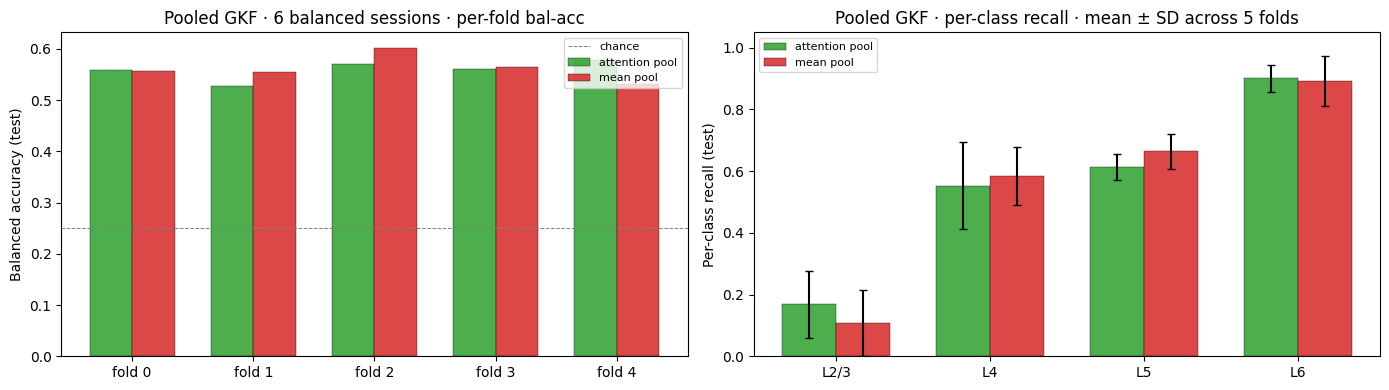

In [24]:
n_pools_run = sum(1 for pk in ['attention','mean'] if results[pk])
if n_pools_run == 0:
    print('No results to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    # (a) per-fold bal-acc, optionally two pools
    ax = axes[0]
    x = np.arange(N_FOLDS)
    width = 0.35
    if results['attention']:
        ax.bar(x - (width/2 if n_pools_run > 1 else 0),
               [s['balanced_accuracy'] for s in results['attention']],
               width if n_pools_run > 1 else 0.7,
               label='attention pool', color='C2', alpha=0.85, edgecolor='k', linewidth=0.3)
    if results['mean']:
        ax.bar(x + width/2, [s['balanced_accuracy'] for s in results['mean']],
               width, label='mean pool', color='C3', alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance')
    ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in range(N_FOLDS)])
    ax.set_ylabel('Balanced accuracy (test)')
    ax.set_title('Pooled GKF · 6 balanced sessions · per-fold bal-acc')
    ax.legend(fontsize=8)

    # (b) per-class recall — mean ± SD
    ax = axes[1]
    x = np.arange(len(LAYER_CLASSES))
    width = 0.35
    for offset, pk, color in [(-width/2, 'attention', 'C2'), (+width/2, 'mean', 'C3')]:
        if not results[pk]: continue
        means = np.array([summaries[pk][f'recall_{c}_mean'] for c in LAYER_CLASSES])
        stds  = np.array([summaries[pk][f'recall_{c}_std']  for c in LAYER_CLASSES])
        ax.bar(x + offset, means, width, yerr=stds, capsize=3, label=f'{pk} pool',
               color=color, alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.set_xticks(x); ax.set_xticklabels(LAYER_CLASSES)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Per-class recall (test)')
    ax.set_title('Pooled GKF · per-class recall · mean ± SD across 5 folds')
    ax.legend(fontsize=8)

    plt.tight_layout(); plt.show()

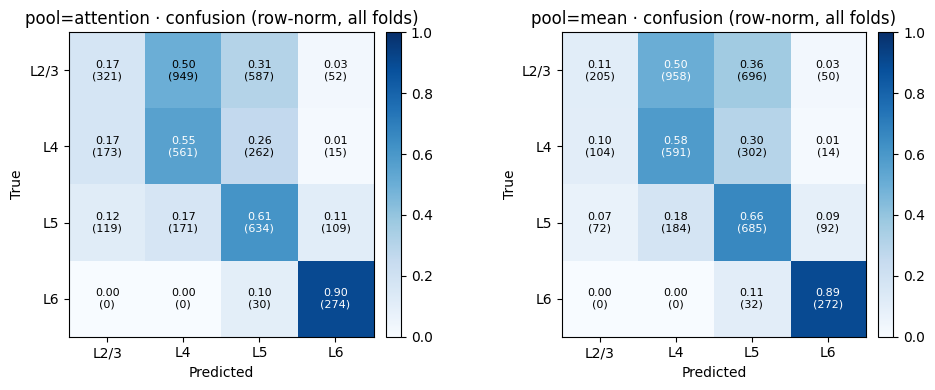

In [25]:
# Confusion matrices for whichever pool(s) ran
pools_with_results = [pk for pk in ['attention','mean'] if results[pk]]
if pools_with_results:
    fig, axes = plt.subplots(1, len(pools_with_results), figsize=(5 * len(pools_with_results), 4),
                              squeeze=False)
    for i, pk in enumerate(pools_with_results):
        ax = axes[0, i]
        Cm = sum(s['confusion_matrix'] for s in results[pk])
        Cn = Cm / Cm.sum(axis=1, keepdims=True).clip(min=1)
        im = ax.imshow(Cn, vmin=0, vmax=1, cmap='Blues')
        for ii in range(Cm.shape[0]):
            for jj in range(Cm.shape[1]):
                ax.text(jj, ii, f'{Cn[ii,jj]:.2f}\n({Cm[ii,jj]})',
                        ha='center', va='center', fontsize=8,
                        color='white' if Cn[ii,jj] > 0.5 else 'black')
        ax.set_xticks(range(len(LAYER_CLASSES))); ax.set_xticklabels(LAYER_CLASSES)
        ax.set_yticks(range(len(LAYER_CLASSES))); ax.set_yticklabels(LAYER_CLASSES)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'pool={pk} · confusion (row-norm, all folds)')
        plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    plt.tight_layout(); plt.show()

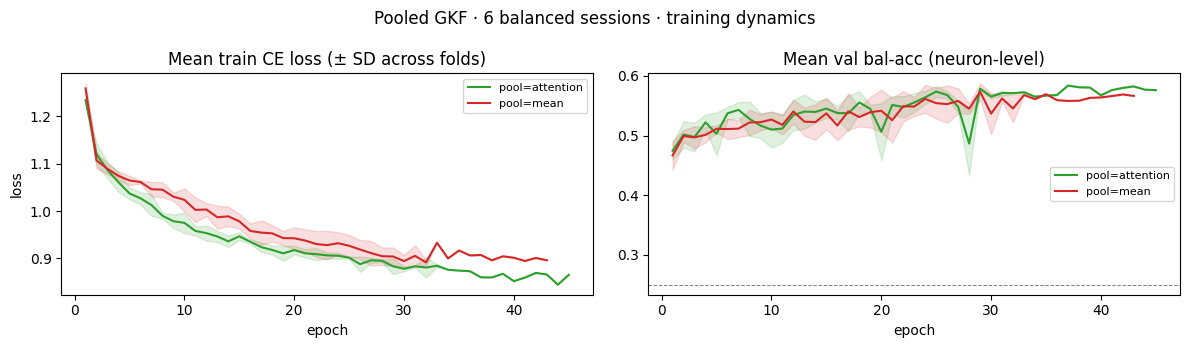

In [26]:
# Training curves (mean ± SD across folds), per-pool overlay
if any(results[pk] for pk in ['attention','mean']):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    for pk, color in [('attention', 'C2'), ('mean', 'C3')]:
        if not results[pk]: continue
        hists = histories[pk]
        max_e = max(len(h) for h in hists)
        loss = np.full((len(hists), max_e), np.nan)
        vacc = np.full((len(hists), max_e), np.nan)
        for ii, h in enumerate(hists):
            loss[ii, :len(h)] = [r['train_loss']  for r in h]
            vacc[ii, :len(h)] = [r['val_bal_acc'] for r in h]
        epochs = np.arange(1, max_e + 1)
        axes[0].plot(epochs, np.nanmean(loss, 0), color=color, label=f'pool={pk}')
        axes[0].fill_between(epochs,
                             np.nanmean(loss, 0) - np.nanstd(loss, 0),
                             np.nanmean(loss, 0) + np.nanstd(loss, 0), color=color, alpha=0.15)
        axes[1].plot(epochs, np.nanmean(vacc, 0), color=color, label=f'pool={pk}')
        axes[1].fill_between(epochs,
                             np.nanmean(vacc, 0) - np.nanstd(vacc, 0),
                             np.nanmean(vacc, 0) + np.nanstd(vacc, 0), color=color, alpha=0.15)
    axes[0].set(title='Mean train CE loss (± SD across folds)', xlabel='epoch', ylabel='loss')
    axes[1].set(title='Mean val bal-acc (neuron-level)',         xlabel='epoch')
    axes[1].axhline(0.25, color='gray', ls='--', lw=0.7)
    for ax in axes: ax.legend(fontsize=8)
    plt.suptitle('Pooled GKF · 6 balanced sessions · training dynamics')
    plt.tight_layout(); plt.show()

## 13 · Persist results

In [27]:
MODEL_NAME = {
    'attention': 'HashAwareDeepSetsCNN_E1_raw_identity_attnpool_pooled_GKF',
    'mean':      'HashAwareDeepSetsCNN_E1_raw_identity_meanpool_pooled_GKF',
}

rows = []
for pk in ['attention', 'mean']:
    if not results[pk]: continue
    s_summary = summaries[pk]
    note_base = (f'Stage 2.3 pooled GKF (planning §Stage 2.5); pool={pk}; '
                 f'sessions={",".join(BALANCED_SESSIONS)}; '
                 f'trace_embed={TRACE_EMBED} hash_embed={HASH_EMBED} '
                 f'row_hidden={ROW_HIDDEN} head_hidden={HEAD_HIDDEN}; '
                 f'n_hashes={N_HASHES}; mismatch removed; padded T={MAX_TRACE_LEN}; '
                 f'masked GAP per trace; loss=inverse_freq')
    for k, score in enumerate(results[pk]):
        per_session_str = ';'.join(
            f'{s}={score["per_session"][s]["bal_acc"]:.3f}/n={score["per_session"][s]["n"]}'
            for s in BALANCED_SESSIONS
        )
        rows.append(make_result_row(
            model_name      = MODEL_NAME[pk],
            input_mode      = 'E1_set_padded_oracle_with_hash_pooled',
            normalization   = 'raw',
            stimulus_family = 'all_padded',
            split_protocol  = f'pooled_GKF{N_FOLDS}_balanced6',
            fold_or_session = f'pool_fold{k}',
            seed            = SEED + k,
            score_dict      = score,
            notes           = (note_base + f'; val_minus_test_gap={score["val_minus_test_gap"]:+.4f}; '
                                f'best_epoch={score["best_epoch"]}/{score["n_epochs_run"]}; '
                                f'per_session_bal_acc={per_session_str}'),
        ))
    rows.append({
        'model_name':        MODEL_NAME[pk],
        'input_mode':        'E1_set_padded_oracle_with_hash_pooled',
        'normalization':     'raw',
        'stimulus_family':   'all_padded',
        'split_protocol':    f'pooled_GKF{N_FOLDS}_balanced6',
        'fold_or_session':   'pool_summary',
        'seed':              SEED,
        'n_neurons':         int(np.mean([sc['n_neurons'] for sc in results[pk]])),
        'balanced_accuracy': float(s_summary['bal_acc_mean']),
        'macro_f1':          float(s_summary['macro_f1_mean']),
        'recall_L23':        float(s_summary['recall_L2/3_mean']),
        'recall_L4':         float(s_summary['recall_L4_mean']),
        'recall_L5':         float(s_summary['recall_L5_mean']),
        'recall_L6':         float(s_summary['recall_L6_mean']),
        'notes':             (f'Stage 2.3 SUMMARY pooled GKF · pool={pk}; '
                              f'sessions={",".join(BALANCED_SESSIONS)}; '
                              f'bal_acc_std={s_summary["bal_acc_std"]:.4f}'),
    })

if rows:
    save_results(rows, 'phase2_stage2_3_pooled_gkf_balanced.parquet')
    print(f'Saved {len(rows)} rows → data/processed/results/phase2_stage2_3_pooled_gkf_balanced.parquet')
else:
    print('No rows to save (no pool ran). Set RUN_ATTENTION_POOL or RUN_MEAN_POOL to True.')

Saved 12 row(s) → data/processed/results/phase2_stage2_3_pooled_gkf_balanced.parquet  (total: 12)
Saved 12 rows → data/processed/results/phase2_stage2_3_pooled_gkf_balanced.parquet


---

### What this notebook does NOT claim

* **No cross-session generalisation claim.** GKF mixes neurons from all 6 sessions across train and test; transfer to a held-out session is the LOSO test (NB 08).
* **No engineered-tier comparison.** Tier-G / Tier-A / multimodal benchmarks remain deferred to the end-of-Phase-2 benchmark notebook.
* **No automatic L2/3 victory.** If pooled L2/3 jumps to ~0.5–0.7, that is *largely* the class-prior change (L2/3 went from minority 22% to majority 45%), not architectural improvement. The fair read is L4 / L5 / L6 deltas vs NB 04, since those priors changed less.
* **No kinetics claim.** Same as before; requires the temporal control suite on the winning model.

### Next notebook

* If pooled GKF is stable (val−test gap small, per-session bal-acc within ±5pp of pool mean) → **NB 08: LOSO across the 6 balanced sessions** (planning §Stage 2.6). Same architecture, same hyperparameters; held out one session at a time.
* If pooled GKF shows a large val−test gap or one session is systematically worse than the rest → investigate that session (depth, mismatch, per-class composition) before LOSO; LOSO will only be more sensitive to the same issue.
* If attention pool overfits visibly more than mean pool, switch the LOSO primary to mean pool.